In [3]:
# Simulción de un proceso MA(1), es to es, ARMA(0,1)
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

In [5]:
ar1 = np.array([1, 0])
ma1 = np.array([1, -0.9])

In [7]:
MA_object1 = ArmaProcess(ar1, ma1)
simulated_data = MA_object1.generate_sample(nsample = 10000)

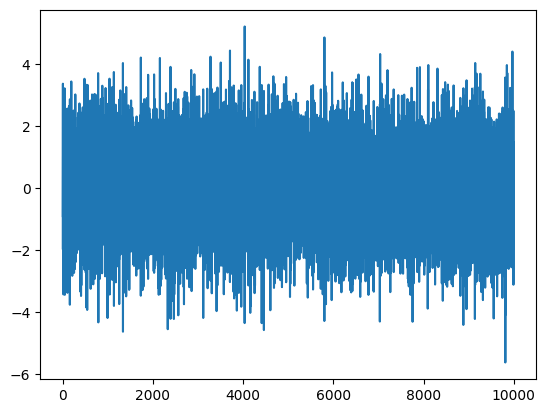

In [9]:
import matplotlib.pyplot as plt
plt.plot((simulated_data))

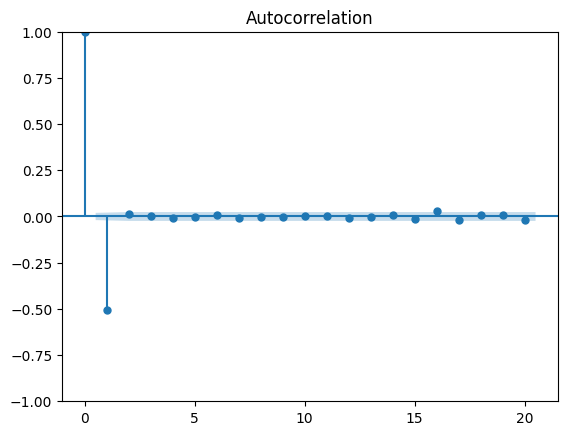

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(simulated_data, lags = 20)
plt.show()

In [13]:
# Procesd de estiimación de párametro
from statsmodels.tsa.arima.model import ARIMA
mod = ARIMA(simulated_data, order = (0,0,1))
result = mod.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                10000
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -14117.083
Date:                Thu, 26 Mar 2026   AIC                          28240.166
Time:                        20:42:39   BIC                          28261.797
Sample:                             0   HQIC                         28247.488
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.001      0.206      0.837      -0.002       0.002
ma.L1         -0.8997      0.004   -203.662      0.000      -0.908      -0.891
sigma2         0.9855      0.014     70.430      0.0

In [14]:
print(result.params[1])

-0.8997429956403622


In [15]:
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Extracción de precios historicos en un rango determinad
apple = yf.download(tickers = 'aapl', start = "2021-04-06", end = "2023-04-06", rounding = True)
apple

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-04-06,122.93,123.82,122.38,123.21,80171300
2021-04-07,124.57,124.59,121.89,122.56,83466700
2021-04-08,126.97,127.00,125.18,125.60,88844600
2021-04-09,129.54,129.58,126.10,126.42,106686700
2021-04-12,127.83,129.40,127.23,129.07,91420000
...,...,...,...,...,...
2023-03-30,160.04,160.15,158.97,159.22,49501700
2023-03-31,162.55,162.64,159.60,160.12,68749800


In [20]:
# Extraemos solo la columna de cierre
apple = apple['Close']['AAPL']
apple

Date
2021-04-06    122.93
2021-04-07    124.57
2021-04-08    126.97
2021-04-09    129.54
2021-04-12    127.83
               ...  
2023-03-30    160.04
2023-03-31    162.55
2023-04-03    163.80
2023-04-04    163.26
2023-04-05    161.42
Name: AAPL, Length: 505, dtype: float64

In [23]:
# Definimos la base de entrenamiento y prueba
apple.index = pd.to_datetime(apple.index)
len_train = int(len(apple) * 0.8)
len_test = int(len(apple) * 0.2)
train = apple[0:len_train]
test = apple[len_train:]

In [25]:
test

Date
2022-11-09    132.74
2022-11-10    144.55
2022-11-11    147.34
2022-11-14    145.94
2022-11-15    147.67
               ...  
2023-03-30    160.04
2023-03-31    162.55
2023-04-03    163.80
2023-04-04    163.26
2023-04-05    161.42
Name: AAPL, Length: 101, dtype: float64

In [27]:
mod = ARIMA(train, order = (0,0,1))
result = mod.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  404
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1415.373
Date:                Thu, 26 Mar 2026   AIC                           2836.747
Time:                        20:42:42   BIC                           2848.751
Sample:                             0   HQIC                          2841.499
                                - 404                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        148.2598      0.778    190.574      0.000     146.735     149.785
ma.L1          0.9279      0.020     45.324      0.000       0.888       0.968
sigma2        64.3306      5.595     11.499      0.0

In [29]:
predicciones = result.forecast(len(test))
predicciones

404    141.667114
405    148.259823
406    148.259823
407    148.259823
408    148.259823
          ...    
500    148.259823
501    148.259823
502    148.259823
503    148.259823
504    148.259823
Name: predicted_mean, Length: 101, dtype: float64

In [31]:
# Colocamos una fecha para poder identificar mejor cada prediccion
test = pd.DataFrame(test)
predicciones = pd.DataFrame(predicciones)
test = test.reset_index()
predicciones = predicciones.reset_index()

In [33]:
test

,Date,AAPL
0,2022-11-09,132.74
1,2022-11-10,144.55
2,2022-11-11,147.34
3,2022-11-14,145.94
4,2022-11-15,147.67
...,...,...
96,2023-03-30,160.04
97,2023-03-31,162.55
98,2023-04-03,163.80
99,2023-04-04,163.26


In [35]:
predicciones

,index,predicted_mean
0,404,141.667114
1,405,148.259823
2,406,148.259823
3,407,148.259823
4,408,148.259823
...,...,...
96,500,148.259823
97,501,148.259823
98,502,148.259823
99,503,148.259823


In [37]:
import numpy as np

acumulador1 = 0
acumulador2 = 0 

for contador in range(0, 101):
    # Usamos .iloc[fila, columna] -> [contador, 1]
    valor_real = test.iloc[contador, 1]
    valor_pred = predicciones.iloc[contador, 1]
    
    acumulador1 += (valor_real - valor_pred) ** 2
    acumulador2 += np.abs((valor_real - valor_pred) / valor_real)

mse = acumulador1 / 101
rmse = np.round(np.sqrt(mse), 2)
mape = np.round((acumulador2 / 101) * 100, 2)

print(f"RMSE = {rmse}, MAPE = {mape}%")

RMSE = 10.63, MAPE = 5.87%


In [39]:
import pandas as pd
import os

os.chdir("/Users/AlanHDLR/Desktop")
df = pd.read_csv("tempNY.csv")
df

,Year,Average,Unnamed: 2
0,1870,53.60,NaN
1,1871,51.13,NaN
2,1872,50.98,NaN
3,1873,50.98,NaN
4,1874,51.34,NaN
...,...,...,...
146,2016,57.18,NaN
147,2017,56.22,NaN
148,2018,55.88,NaN
149,2019,55.62,NaN


In [43]:
df = df.drop("Unnamed: 2", axis = 1)
df

,Year,Average
0,1870,53.60
1,1871,51.13
2,1872,50.98
3,1873,50.98
4,1874,51.34
...,...,...
146,2016,57.18
147,2017,56.22
148,2018,55.88
149,2019,55.62


In [45]:
# Cambio de indice principal 
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


<Axes: xlabel='Year'>

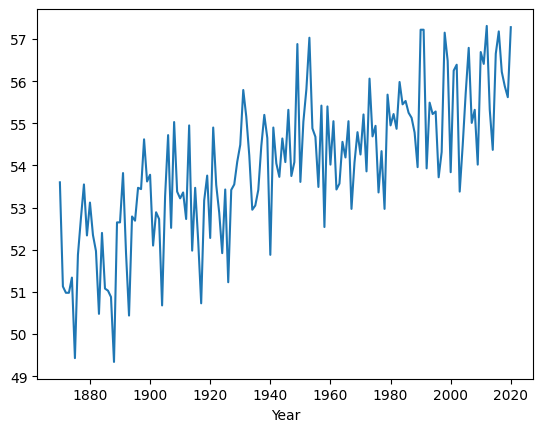

In [47]:
df["Average"].plot()

In [51]:
# Realizacion de la prueba Dickey-Fuller
# H0: La serie es NO ESTACIONARIA
# Ha: La serie SI ES ESTACIONARIA

from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Average"])
print("El valor p de la prueba de Dickey-Fuller es: ", result[1])

El valor p de la prueba de Dickey-Fuller es:  0.8417172538965364


In [53]:
result

(-0.7191855951167331,
 0.8417172538965364,
 10,
 140,
 {'1%': -3.4779446621720114,
  '5%': -2.8824156122448983,
  '10%': -2.577901887755102},
 444.8915181430483)

### Conclusión: No hay evidencia estadistica para rechazar H0(y por lo tanto decri que la serie esa estacionaria)

In [56]:
# Aplicar primeras diferencias
df["temp_change"] = df["Average"].diff()
df

,Average,temp_change
Year,,
1870,53.60,NaN
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
...,...,...
2016,57.18,0.53
2017,56.22,-0.96
2018,55.88,-0.34


In [58]:
# Eliminamos el primer renglon para no entrenar con el dato NaN
df = df.dropna()
df

,Average,temp_change
Year,,
1871,51.13,-2.47
1872,50.98,-0.15
1873,50.98,0.00
1874,51.34,0.36
1875,49.43,-1.91
...,...,...
2016,57.18,0.53
2017,56.22,-0.96
2018,55.88,-0.34


In [60]:
# Aplicación de la prueba Dickey-Fuller sobre las diferencias
result2 = adfuller(df["temp_change"])
print("El valor p de la prueba Dickey-Fuller es: ", result2[1])

El valor p de la prueba Dickey-Fuller es:  8.361907414786182e-14


<Axes: xlabel='Year'>

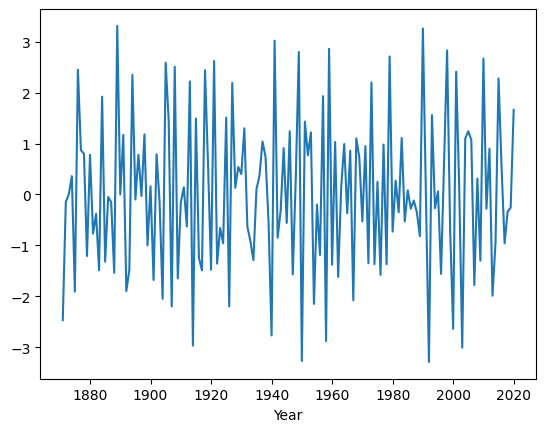

In [62]:
df["temp_change"].plot()

### Conclusión: La serie transformada de diferencias SI ES ESTACIONARIA

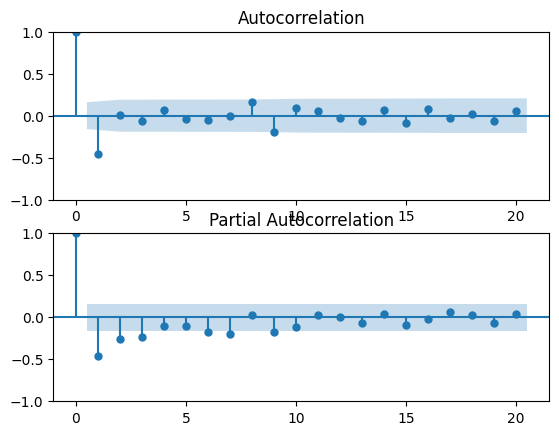

In [67]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2,1) 

# Graficación de la función de autocorrelación ACF
plot_acf(df["temp_change"], lags = 20, ax = axes[0], alpha = 0.05)

# Graficación de la función de autocorrelación parcial PACF
plot_pacf(df["temp_change"], lags = 20, ax = axes[1], alpha = 0.05)

plt.show()

In [69]:
# Importación del modulo para estimar un modelos ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Ajustar los datos a un modelo AR(1) e imprimirsi AIC:
mod_ar1 = ARIMA(df["temp_change"], order = (1,0,0))
res_ar1 = mod_ar1.fit()
print("El AIC para AR(1) es: ", res_ar1.aic)

El AIC para AR(1) es:  519.9693852277926


In [71]:
# Ajustar los datos a un modelo AR(2) e imprimirsi AIC:
mod_ar2 = ARIMA(df["temp_change"], order = (2,0,0))
res_ar2 = mod_ar2.fit()
print("El AIC para AR(1) es: ", res_ar2.aic)

El AIC para AR(1) es:  510.48447045590717


In [73]:
# Ajustar los datos a un modelo ARma(111) e imprimirsi AIC:
mod_arma11 = ARIMA(df["temp_change"], order = (1,0,1))
res_arma11 = mod_arma11.fit()
print("El AIC para ARMA(1,1) es: ", res_arma11.aic)

El AIC para ARMA(1,1) es:  473.8297266349273


### Conclusión: La seríe de tiempo original de temperaturas se modela bien con ARIMA(1,1,1)

In [78]:
df = pd.read_csv("TempNY.csv")
df = df.drop("Unnamed: 2", axis = 1)
df.index = df["Year"]
df = df.drop("Year", axis = 1)
df

,Average
Year,
1870,53.60
1871,51.13
1872,50.98
1873,50.98
1874,51.34
...,...
2016,57.18
2017,56.22
2018,55.88


In [80]:
# Importación del módulo ARIMA de statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

# Pronostico de temperaturas usando un modelo ARIMA(1,1,1)
mod = ARIMA(df["Average"], order = (1,1,1))
res = mod.fit()

print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  151
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -238.826
Date:                Thu, 26 Mar 2026   AIC                            483.652
Time:                        21:13:33   BIC                            492.683
Sample:                             0   HQIC                           487.321
                                - 151                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0646      0.109      0.590      0.555      -0.150       0.279
ma.L1         -0.8669      0.057    -15.261      0.000      -0.978      -0.756
sigma2         1.4020      0.199      7.043      0.0

In [82]:
# Pronostico puntual de los proximos 5 años
predicciones = res.forecast(5)
predicciones

151    56.150447
152    56.077505
153    56.072795
154    56.072490
155    56.072471
Name: predicted_mean, dtype: float64

In [84]:
# Pronóstico por intervalo de los proximos 5 años
conf = res.get_forecast(5).conf_int(alpha = 0.05)
conf

,lower Average,upper Average
151,53.829710,58.471183
152,53.711871,58.443138
153,53.683072,58.462517
154,53.659996,58.484985
155,53.637485,58.507456
